# $N^2$ in the north Pacific -6% Solar experiments: Figure S9

## Includes contributions from temperature and salinity.

Last modified August 25 2025

In [14]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import netCDF4

# Load T, S data and compute density and $N^2$

In [15]:
# Note lat/lon bounds may be different

In [16]:
# load FLOR -6% Solar data
FLOR_m6_temp = xr.open_dataarray('./MODEL_OUT/NPacific/temp_FLOR_m6p0sol_CTL1860_tigercpu_intelmpi_18_576PE_0101-0200_NPacific.nc')
FLOR_m6_salt = xr.open_dataarray('./MODEL_OUT/NPacific/salt_FLOR_m6p0sol_CTL1860_tigercpu_intelmpi_18_576PE_0101-0200_NPacific.nc')
#FLOR_m6_rho = xr.open_dataarray('./MODEL_OUT/NPacific/pot_rho_0_FLOR_m6p0sol_CTL1860_tigercpu_intelmpi_18_576PE_0101-0200_NPacific.nc')
FLOR_ds_m6 = xr.merge([FLOR_m6_temp,FLOR_m6_salt])#,FLOR_m6_rho])

In [17]:
# load FLOR control data
FLOR_temp = xr.open_dataarray('./MODEL_OUT/NPacific/temp_FLOR_CTL1860_newdiag_tigercpu_intelmpi_18_576PE_0101-0200_NPacific.nc')
FLOR_salt = xr.open_dataarray('./MODEL_OUT/NPacific/salt_FLOR_CTL1860_newdiag_tigercpu_intelmpi_18_576PE_0101-0200_NPacific.nc')
#FLOR_rho = xr.open_dataarray('./MODEL_OUT/NPacific/pot_rho_0_FLOR_CTL1860_newdiag_tigercpu_intelmpi_18_576PE_0101-0200_NPacific.nc')
FLOR_ds_CTRL = xr.merge([FLOR_temp,FLOR_salt])#,FLOR_rho])

In [18]:
# load CM2.1 -6% solar data
CM21_m6_temp = xr.open_dataarray('./MODEL_OUT/NPacific/temp_CM2.1p1_CTL1860_m6pctSolar_tigercpu_intelmpi_18_80PE_0101-0200_NPacific.nc')
CM21_m6_salt = xr.open_dataarray('./MODEL_OUT/NPacific/salt_CM2.1p1_CTL1860_m6pctSolar_tigercpu_intelmpi_18_80PE_0101-0200_NPacific.nc')
#CM21_m6_rho = xr.open_dataarray('./MODEL_OUT/NPacific/pot_rho_0_CM2.1p1_CTL1860_m6pctSolar_tigercpu_intelmpi_18_80PE_0101-0200_NPacific.nc')
CM21_ds_m6 = xr.merge([CM21_m6_temp,CM21_m6_salt])#,CM21_m6_rho])

In [19]:
# load CM2.1 control data
CM21_temp = xr.open_dataarray('./MODEL_OUT/NPacific/temp_CM2.1p1_CTL1860_tigercpu_intelmpi_18_80PE_0101-0200_NPacific.nc')
CM21_salt = xr.open_dataarray('./MODEL_OUT/NPacific/salt_CM2.1p1_CTL1860_tigercpu_intelmpi_18_80PE_0101-0200_NPacific.nc')
#CM21_rho = xr.open_dataarray('./MODEL_OUT/NPacific/pot_rho_0_CM2.1p1_CTL1860_tigercpu_intelmpi_18_80PE_0101-0200_NPacific.nc')
CM21_ds_CTRL = xr.merge([CM21_temp,CM21_salt])#,CM21_rho])

$$N^2 = -\frac{g}{\rho_0} \frac{\partial\rho(z)}{\partial z}$$

In [20]:
import gsw

In [21]:
print(FLOR_m6_salt.long_name, FLOR_m6_salt.units)
print(FLOR_m6_temp.long_name, FLOR_m6_temp.units)

Practical Salinity psu
Potential temperature degrees C


In [22]:
# convert practical salinity to absolute salinity and potential temperature to conservative temperature

def SP_to_SA(SP,depth):
    pressure = gsw.p_from_z(-depth,SP.yt_ocean) # get sea pressure from height, lat (negative in ocean)
    SA = gsw.SA_from_SP(SP,pressure,SP.xt_ocean,SP.yt_ocean) 
    return SA, pressure

def convert_TS_forN2(practical_salinity, potential_temp, depth):
    # inputs: practical salinity (unitless/psu), potential temperature (deg C)
    SA, pressure = SP_to_SA(practical_salinity,depth)
    CT = gsw.CT_from_pt(SA, potential_temp)

    return SA, CT, pressure

# Signature: gsw.SA_from_SP(SP, p, lon, lat)
# Docstring:
# Calculates Absolute Salinity from Practical Salinity.  Since SP is
# non-negative by definition, this function changes any negative input
# values of SP to be zero.

# Parameters
# ----------
# SP : array-like
#     Practical Salinity (PSS-78), unitless
# p : array-like
#     Sea pressure (absolute pressure minus 10.1325 dbar), dbar
# lon : array-like
#     Longitude, -360 to 360 degrees
# lat : array-like
#     Latitude, -90 to 90 degrees

# Returns
# -------
# SA : array-like, g/kg
#     Absolute Salinity
############################################
# Signature: gsw.CT_from_pt(SA, pt)
# Docstring:
# Calculates Conservative Temperature of seawater from potential
# temperature (whose reference sea pressure is zero dbar).

# Parameters
# ----------
# SA : array-like
#     Absolute Salinity, g/kg
# pt : array-like
#     Potential temperature referenced to a sea pressure, degrees C

# Returns
# -------
# CT : array-like, deg C
#     Conservative Temperature (ITS-90)

In [23]:
def get_N2(practical_salinity, potential_temperature, depth):
    
    salt, temp, pressure = convert_TS_forN2(practical_salinity, potential_temperature, depth)

    # Expand pressure along longitude dimension if needed
    if pressure.shape != salt.shape:
        pressure = pressure.expand_dims(dim={"xt_ocean": salt.xt_ocean}, axis=-1)

    # Ensure that depth (st_ocean) is the second dimension (after time)
    salt = salt.transpose("time", "st_ocean", ...)  
    temp = temp.transpose("time", "st_ocean", ...)  
    #pressure = pressure.transpose("time", "st_ocean", ...)  

    # Compute N2 and p_mid along the depth axis (axis=1 since time is first)
    N2, p_mid = gsw.Nsquared(salt, temp, pressure, axis=1)  # Depth is now the second axis

    # Debugging: Print shapes to verify
    # print("salt shape:", salt.shape)
    # print("N2 shape:", N2.shape)
    # print("Original st_ocean shape:", salt.st_ocean.shape)
    # print("Modified st_ocean shape:", salt.st_ocean[:-1].shape)

    # Ensure coordinates match
    coords = {k: v for k, v in salt.coords.items()}  # Copy coordinates 
    if "st_ocean" in coords:
        coords["st_ocean"] = salt.st_ocean[:-1]  # Adjust depth dimension 
    
    # Convert back to original order 
    N2_da = xr.DataArray(
        N2,
        dims=salt.dims,  # Keep the same dimension names 
        coords=coords,  # Assign adjusted coordinates 
        name="N2",
        attrs={"units": "s^-2", "description": "Buoyancy frequency squared"}
    ).transpose(*salt.dims)  # Reorder to match the original dimensions

    return N2_da


# Signature: gsw.Nsquared(SA, CT, p, lat=None, axis=0)
# Docstring:
# Calculate the square of the buoyancy frequency.

# Parameters
# ----------
# SA : array-like
#     Absolute Salinity, g/kg
# CT : array-like
#     Conservative Temperature (ITS-90), degrees C
# p : array-like
#     Sea pressure (absolute pressure minus 10.1325 dbar), dbar
# lat : array-like, 1-D, optional
#     Latitude, degrees.
# axis : int, optional
#     The dimension along which pressure increases.

# Returns
# -------
# N2 : array
#     Buoyancy frequency-squared at pressure midpoints, 1/s^2.
#     The shape along the pressure axis dimension is one
#     less than that of the inputs.
#     (Frequency N is in radians per second.)
# p_mid : array
#     Pressure at midpoints of p, dbar.
#     The array shape matches N2.

In [24]:
# box
def get_box(da, lat1=40, lat2=60, lon1=-190, lon2=-140):
    # not an average; just selecting an area
    da_new = da.sel(xt_ocean=slice(lon1,lon2),
                    yt_ocean = slice(lat1, lat2))
    return da_new

In [25]:
FLOR_ds_m6_box = get_box(FLOR_ds_m6)
FLOR_ds_CTRL_box = get_box(FLOR_ds_CTRL)

CM21_ds_m6_box = get_box(CM21_ds_m6)
CM21_ds_CTRL_box = get_box(CM21_ds_CTRL)

In [26]:
# Specify the depth range (helps when taking depth mean)
depth = FLOR_ds_CTRL_box.st_ocean

# Compute $N^2$ (skip if already done)

takes a few minutes (monthly data)

In [19]:
# compute N^2 using the Control temp and salt
N2_FLOR_CTRL = get_N2(FLOR_ds_CTRL_box.salt,FLOR_ds_CTRL_box.temp,depth)

In [22]:
N2_FLOR_CTRL.to_netcdf('./processed_data/N2_FLOR_CTRL_0101-0200_NPacific_box1.nc')

In [23]:
N2_CM21_CTRL = get_N2(CM21_ds_CTRL_box.salt,CM21_ds_CTRL_box.temp,depth)

In [24]:
N2_CM21_CTRL.to_netcdf('./processed_data/N2_CM2.1p1_CTRL_0101-0200_NPacific_box1.nc')

In [25]:
# compute N^2 using the -6% Solar temp and salt
N2_FLOR_m6 = get_N2(FLOR_ds_m6_box.salt,FLOR_ds_m6_box.temp,depth)
N2_FLOR_m6.to_netcdf('./processed_data/N2_FLOR_m6_0101-0200_NPacific_box1.nc')

In [26]:
N2_CM21_m6 = get_N2(CM21_ds_m6_box.salt,CM21_ds_m6_box.temp,depth)
N2_CM21_m6.to_netcdf('./processed_data/N2_CM2.1p1_m6_0101-0200_NPacific_box1.nc')

# compute with vertically-averaged S and T for different time periods

In [ ]:
# control (takes several minutes)

# compute N^2 using the Control salt and mean temp
N2_FLOR_CTRL_Tmean = get_N2(FLOR_ds_CTRL_box.salt,FLOR_ds_CTRL_box.temp.mean('st_ocean'),depth)
N2_CM21_CTRL_Tmean = get_N2(CM21_ds_CTRL_box.salt,CM21_ds_CTRL_box.temp.mean('st_ocean'),depth)

# compute N^2 using the Control temp and mean salt
N2_FLOR_CTRL_Smean = get_N2(FLOR_ds_CTRL_box.salt.mean('st_ocean'),FLOR_ds_CTRL_box.temp,depth)
N2_CM21_CTRL_Smean = get_N2(CM21_ds_CTRL_box.salt.mean('st_ocean'),CM21_ds_CTRL_box.temp,depth)

In [ ]:
# save to netcdf
N2_FLOR_CTRL_Tmean.to_netcdf('./processed_data/N2_FLOR_CTRL_Tmean_0101-0200_NPacific_box1.nc')
N2_CM21_CTRL_Tmean.to_netcdf('./processed_data/N2_CM2.1p1_CTRL_Tmean_0101-0200_NPacific_box1.nc')

N2_FLOR_CTRL_Smean.to_netcdf('./processed_data/N2_FLOR_CTRL_Smean_0101-0200_NPacific_box1.nc')
N2_CM21_CTRL_Smean.to_netcdf('./processed_data/N2_CM2.1p1_CTRL_Smean_0101-0200_NPacific_box1.nc')

In [ ]:
# -6% Solar

# compute N^2 using the Control salt and mean temp
N2_FLOR_m6_Tmean = get_N2(FLOR_ds_m6_box.salt,FLOR_ds_m6_box.temp.mean('st_ocean'),depth)
N2_CM21_m6_Tmean = get_N2(CM21_ds_m6_box.salt,CM21_ds_m6_box.temp.mean('st_ocean'),depth)

# compute N^2 using the Control temp and mean salt
N2_FLOR_m6_Smean = get_N2(FLOR_ds_m6_box.salt.mean('st_ocean'),FLOR_ds_m6_box.temp,depth)
N2_CM21_m6_Smean = get_N2(CM21_ds_m6_box.salt.mean('st_ocean'),CM21_ds_m6_box.temp,depth)

In [ ]:
# save to netcdf
N2_FLOR_m6_Tmean.to_netcdf('./processed_data/N2_FLOR_m6_Tmean_0101-0200_NPacific_box1.nc')
N2_CM21_m6_Tmean.to_netcdf('./processed_data/N2_CM2.1p1_m6_Tmean_0101-0200_NPacific_box1.nc')

N2_FLOR_m6_Smean.to_netcdf('./processed_data/N2_FLOR_m6_Smean_0101-0200_NPacific_box1.nc')
N2_CM21_m6_Smean.to_netcdf('./processed_data/N2_CM2.1p1_m6_Smean_0101-0200_NPacific_box1.nc')

# If already computed, load data

In [27]:
N2_FLOR_CTRL = xr.open_dataarray('./processed_data/N2_FLOR_CTRL_0101-0200_NPacific_box1.nc')
N2_CM21_CTRL = xr.open_dataarray('./processed_data/N2_CM2.1p1_CTRL_0101-0200_NPacific_box1.nc')
N2_FLOR_m6 = xr.open_dataarray('./processed_data/N2_FLOR_m6_0101-0200_NPacific_box1.nc')
N2_CM21_m6 = xr.open_dataarray('./processed_data/N2_CM2.1p1_m6_0101-0200_NPacific_box1.nc')

In [28]:
N2_FLOR_CTRL_Tmean = xr.open_dataarray('./processed_data/N2_FLOR_CTRL_Tmean_0101-0200_NPacific_box1.nc')
N2_CM21_CTRL_Tmean = xr.open_dataarray('./processed_data/N2_CM2.1p1_CTRL_Tmean_0101-0200_NPacific_box1.nc')
N2_FLOR_CTRL_Smean = xr.open_dataarray('./processed_data/N2_FLOR_CTRL_Smean_0101-0200_NPacific_box1.nc')
N2_CM21_CTRL_Smean = xr.open_dataarray('./processed_data/N2_CM2.1p1_CTRL_Smean_0101-0200_NPacific_box1.nc')

N2_FLOR_m6_Tmean = xr.open_dataarray('./processed_data/N2_FLOR_m6_Tmean_0101-0200_NPacific_box1.nc')
N2_CM21_m6_Tmean = xr.open_dataarray('./processed_data/N2_CM2.1p1_m6_Tmean_0101-0200_NPacific_box1.nc')
N2_FLOR_m6_Smean = xr.open_dataarray('./processed_data/N2_FLOR_m6_Smean_0101-0200_NPacific_box1.nc')
N2_CM21_m6_Smean = xr.open_dataarray('./processed_data/N2_CM2.1p1_m6_Smean_0101-0200_NPacific_box1.nc')

In [43]:
# select first 10 years
N2_FLOR_m6_10 = N2_FLOR_m6.isel(time=slice(0,12*10))
N2_CM21_m6_10 = N2_CM21_m6.isel(time=slice(0,12*10))
N2_FLOR_m6_10_Tmean = N2_FLOR_m6_Tmean.isel(time=slice(0,12*10))
N2_CM21_m6_10_Tmean = N2_CM21_m6_Tmean.isel(time=slice(0,12*10))
N2_FLOR_m6_10_Smean = N2_FLOR_m6_Smean.isel(time=slice(0,12*10))
N2_CM21_m6_10_Smean = N2_CM21_m6_Smean.isel(time=slice(0,12*10))

In [44]:
# select years 40-50
N2_FLOR_m6_end = N2_FLOR_m6.isel(time=slice(40*12,50*12))
N2_CM21_m6_end = N2_CM21_m6.isel(time=slice(40*12,50*12))
N2_FLOR_m6_end_Tmean = N2_FLOR_m6_Tmean.isel(time=slice(40*12,50*12))
N2_CM21_m6_end_Tmean = N2_CM21_m6_Tmean.isel(time=slice(40*12,50*12))
N2_FLOR_m6_end_Smean = N2_FLOR_m6_Smean.isel(time=slice(40*12,50*12))
N2_CM21_m6_end_Smean = N2_CM21_m6_Smean.isel(time=slice(40*12,50*12))

In [17]:
# # compute N^2 using the -6% temp and salt: years 101-110
# N2_FLOR_m6_10 = get_N2(FLOR_ds_m6_box.salt.isel(time=slice(0,12*10)),FLOR_ds_m6_box.temp.isel(time=slice(0,12*10)),depth)
# N2_CM21_m6_10 = get_N2(CM21_ds_m6_box.salt.isel(time=slice(0,12*10)),CM21_ds_m6_box.temp.isel(time=slice(0,12*10)),depth)

# N2_FLOR_m6_10_Tmean = get_N2(FLOR_ds_m6_box.salt.isel(time=slice(0,12*10)),FLOR_ds_m6_box.temp.isel(time=slice(0,12*10)).mean('st_ocean'),depth)
# N2_CM21_m6_10_Tmean = get_N2(CM21_ds_m6_box.salt.isel(time=slice(0,12*10)),CM21_ds_m6_box.temp.isel(time=slice(0,12*10)).mean('st_ocean'),depth)

# N2_FLOR_m6_10_Smean = get_N2(FLOR_ds_m6_box.salt.isel(time=slice(0,12*10)).mean('st_ocean'),FLOR_ds_m6_box.temp.isel(time=slice(0,12*10)),depth)
# N2_CM21_m6_10_Smean = get_N2(CM21_ds_m6_box.salt.isel(time=slice(0,12*10)).mean('st_ocean'),CM21_ds_m6_box.temp.isel(time=slice(0,12*10)),depth)


In [18]:
# # compute N^2 using the -6% temp and salt: years 140-150
# N2_FLOR_m6_end = get_N2(FLOR_ds_m6_box.salt.isel(time=slice(40*12,50*12)),FLOR_ds_m6_box.temp.isel(time=slice(40*12,50*12)),depth)
# N2_CM21_m6_end = get_N2(CM21_ds_m6_box.salt.isel(time=slice(40*12,50*12)),CM21_ds_m6_box.temp.isel(time=slice(40*12,50*12)),depth)

# N2_FLOR_m6_end_Tmean = get_N2(FLOR_ds_m6_box.salt.isel(time=slice(40*12,50*12)),FLOR_ds_m6_box.temp.isel(time=slice(40*12,50*12)).mean('st_ocean'),depth)
# N2_CM21_m6_end_Tmean = get_N2(CM21_ds_m6_box.salt.isel(time=slice(40*12,50*12)),CM21_ds_m6_box.temp.isel(time=slice(40*12,50*12)).mean('st_ocean'),depth)

# N2_FLOR_m6_end_Smean = get_N2(FLOR_ds_m6_box.salt.isel(time=slice(40*12,50*12)).mean('st_ocean'),FLOR_ds_m6_box.temp.isel(time=slice(40*12,50*12)),depth)
# N2_CM21_m6_end_Smean = get_N2(CM21_ds_m6_box.salt.isel(time=slice(40*12,50*12)).mean('st_ocean'),CM21_ds_m6_box.temp.isel(time=slice(40*12,50*12)),depth)


# Functions for JFM mean and inset axes

In [39]:
# Get JFM mean
def JFM_mean(da):
    da_JFM_mean = da.groupby('time.month').mean('time').isel(month=slice(0,3)).mean('month')
    return da_JFM_mean

In [46]:
# Create an inset axis for the tiny bar chart in the upper-right corner
def make_inset_axis(ax_subplot, bar_labels, bar_values_list,
                    bbox=(0.6, 0.5, 0.3, 0.4), 
                    ylim=(-7e-6, 7e-6),
                   title='', leftylabel="[s$^{-2}$]", rightylabel="0-500m"):
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    
    inset_ax = inset_axes(ax_subplot,
                          width="100%",   # 100% of the bbox
                          height="100%",  # 100% of the bbox
                          loc='center',   # anchor center of inset to bbox
                          bbox_to_anchor=bbox,
                          bbox_transform=ax_subplot.transAxes,
                          borderpad=0)

    # Plot a bar chart with sample values
    inset_ax.bar(bar_labels, bar_values_list, color=['k', 'b', 'r'])
    inset_ax.set_ylim(ylim)
    inset_ax.set_xticklabels([])  # Hide x labels
    inset_ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    inset_ax.set_title(title, fontsize=20)
    #inset_ax.set_frame_on(False)  # Remove frame

    # Left y-axis
    inset_ax.set_ylabel(leftylabel, rotation=90, labelpad=-5)
    inset_ax.yaxis.set_label_position("left")
    # Right y-axis
    ax_right = inset_ax.twinx()  # creates a second y-axis on the right
    ax_right.set_ylabel(rightylabel, rotation=270, labelpad=20)
    ax_right.yaxis.set_label_position("right")
    ax_right.set_yticks([])          # removes tick positions
    ax_right.tick_params(right=False)  # ensures no ticks are drawn

    # zero line
    inset_ax.axhline(0, color='k', linewidth=1, linestyle='--')
    
    return inset_ax

# Plot Figure

In [41]:
def depth_weighted_mean(da, dim='st_ocean'):
    d = da[dim]
    # thickness between layers
    dz = d.diff(dim) 
    
    # weight by dz
    da_weighted = (da * d.diff(dim)).sum()
    # pad so it's the same length as da, with first layer = 5 m
    dz = dz.reindex({dim: da[dim]}, method="bfill")
    dz[0] = 5  # set first layer to 5 m thick
    
    # weighted mean
    weighted_sum = (da * dz).sum(dim=dim, skipna=True)
    total_thickness = dz.sum(dim=dim, skipna=True)
    
    return weighted_sum / total_thickness

def plot_N2(ax, TS, Tmean, Smean):
    # CTRL
    TS.plot(ax=ax, label=r'$N^2(T,S)$', y='st_ocean', color='k')
    Tmean.plot(ax=ax, label=r'$N^2(\overline{T},S)$', y='st_ocean', color='b')
    Smean.plot(ax=ax, label=r'$N^2(T,\overline{S})$', y='st_ocean', color='r')

    ax.set_ylim(2000, 0)
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.axvline(0, color='gray', zorder=0)
    ax.grid(linestyle='--')
    
    # Rotate x ticks
    ax.tick_params(axis='x', rotation=30)

    # plot signs
    # Get means for upper 500 m
    mean1_1 = depth_weighted_mean(TS.sel(st_ocean=slice(0, 500)))
    mean2_1 = depth_weighted_mean(Tmean.sel(st_ocean=slice(0, 500)))
    mean3_1 = depth_weighted_mean(Smean.sel(st_ocean=slice(0, 500)))#.mean()

    # Get means for 500-2000 m
    mean1_2 = depth_weighted_mean(TS.sel(st_ocean=slice(500,2000)))#.mean()
    mean2_2 = depth_weighted_mean(Tmean.sel(st_ocean=slice(500,2000)))#.mean()
    mean3_2 = depth_weighted_mean(Smean.sel(st_ocean=slice(500,2000))).mean()

    return np.array([mean1_1, mean2_1, mean3_1]), np.array([mean1_2, mean2_2, mean3_2])


/tmp/ipykernel_2574223/3266993265.py:120: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


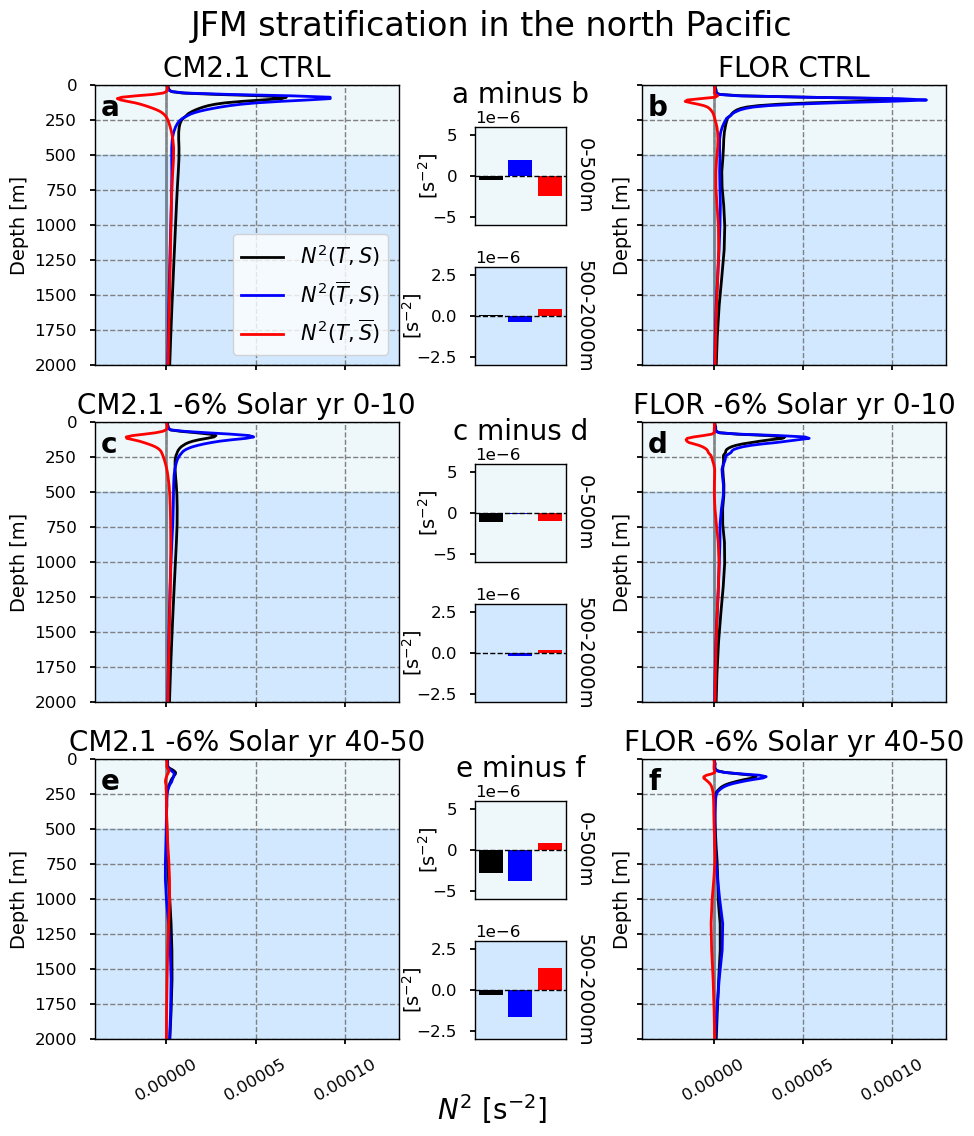

In [52]:
plt.style.use('../func/paper.mplstyle')

fig, ax = plt.subplots(3,2, figsize=(10, 12), constrained_layout=False, sharex=True, sharey=True)  

###### plot N2 ###### 
# (area-weighted mean)
# Compute latitude weights
lat_rad = np.deg2rad(JFM_mean(N2_CM21_CTRL)['yt_ocean'])
weights = np.cos(lat_rad)
# Use broadcasting to match da_box shape
weights_CM21, _ = xr.broadcast(weights, JFM_mean(N2_CM21_CTRL))

# Compute latitude weights
lat_rad = np.deg2rad(JFM_mean(N2_FLOR_CTRL)['yt_ocean'])
weights = np.cos(lat_rad)
# Use broadcasting to match da_box shape
weights_FLOR, _ = xr.broadcast(weights, JFM_mean(N2_FLOR_CTRL))

### Control ###
CM21_CTRL_500, CM21_CTRL_2000 = plot_N2(ax[0,0],
        JFM_mean(N2_CM21_CTRL).weighted(weights_CM21).mean(('yt_ocean','xt_ocean')),
        JFM_mean(N2_CM21_CTRL_Tmean).weighted(weights_CM21).mean(('yt_ocean','xt_ocean')),
        JFM_mean(N2_CM21_CTRL_Smean).weighted(weights_CM21).mean(('yt_ocean','xt_ocean')))
FLOR_CTRL_500, FLOR_CTRL_2000 = plot_N2(ax[0,1],
        JFM_mean(N2_FLOR_CTRL).weighted(weights_FLOR).mean(('yt_ocean','xt_ocean')),
        JFM_mean(N2_FLOR_CTRL_Tmean).weighted(weights_FLOR).mean(('yt_ocean','xt_ocean')),
        JFM_mean(N2_FLOR_CTRL_Smean).weighted(weights_FLOR).mean(('yt_ocean','xt_ocean')))

### beginning of timeseries ###
CM21_m6_10_500, CM21_m6_10_2000 = plot_N2(ax[1,0],
        JFM_mean(N2_CM21_m6_10).weighted(weights_CM21).mean(('yt_ocean','xt_ocean')),
        JFM_mean(N2_CM21_m6_10_Tmean).weighted(weights_CM21).mean(('yt_ocean','xt_ocean')),
        JFM_mean(N2_CM21_m6_10_Smean).weighted(weights_CM21).mean(('yt_ocean','xt_ocean')))
FLOR_m6_10_500, FLOR_m6_10_2000 = plot_N2(ax[1,1],
        JFM_mean(N2_FLOR_m6_10).weighted(weights_FLOR).mean(('yt_ocean','xt_ocean')),
        JFM_mean(N2_FLOR_m6_10_Tmean).weighted(weights_FLOR).mean(('yt_ocean','xt_ocean')),
        JFM_mean(N2_FLOR_m6_10_Smean).weighted(weights_FLOR).mean(('yt_ocean','xt_ocean')))

### end of timeseries ###
CM21_m6_end_500, CM21_m6_end_2000 = plot_N2(ax[2,0],
        JFM_mean(N2_CM21_m6_end).weighted(weights_CM21).mean(('yt_ocean','xt_ocean')),
        JFM_mean(N2_CM21_m6_end_Tmean).weighted(weights_CM21).mean(('yt_ocean','xt_ocean')),
        JFM_mean(N2_CM21_m6_end_Smean).weighted(weights_CM21).mean(('yt_ocean','xt_ocean')))
FLOR_m6_end_500, FLOR_m6_end_2000 = plot_N2(ax[2,1],
        JFM_mean(N2_FLOR_m6_end).weighted(weights_FLOR).mean(('yt_ocean','xt_ocean')),
        JFM_mean(N2_FLOR_m6_end_Tmean).weighted(weights_FLOR).mean(('yt_ocean','xt_ocean')),
        JFM_mean(N2_FLOR_m6_end_Smean).weighted(weights_FLOR).mean(('yt_ocean','xt_ocean')))

# label the subplots
import string
axes = ax.flatten()
for i, axi in enumerate(axes):
    axi.text(0.02, 0.97, f"{string.ascii_lowercase[i]}",
             transform=axi.transAxes,
             fontsize=20, fontweight="bold",
             va="top", ha="left")

# plot bars on inset axes and shade colors
lightblue_alpha = (173/255, 216/255, 230/255, 0.2)   # lightblue RGBA
dodgerblue_alpha = (30/255, 144/255, 255/255, 0.2)    # dodgerblue RGBA

inset_height = 0.35

bar_labels = ['1','2','3']
inset_top = make_inset_axis(ax[0,0], bar_labels, CM21_CTRL_500 - FLOR_CTRL_500, bbox=(1.25, 0.5, 0.3, inset_height), ylim=(-6e-6, 6e-6),
               title='a minus b', rightylabel='0-500m')
inset_top.set_facecolor(lightblue_alpha)
inset_bot = make_inset_axis(ax[0,0], bar_labels, CM21_CTRL_2000 - FLOR_CTRL_2000, bbox=(1.25, 0, 0.3, inset_height), ylim=(-3e-6, 3e-6),
                           title='', rightylabel='500-2000m')
inset_bot.set_facecolor(dodgerblue_alpha)

inset_top = make_inset_axis(ax[1,0], bar_labels, CM21_m6_10_500 - FLOR_m6_10_500, bbox=(1.25, 0.5, 0.3, inset_height), ylim=(-6e-6, 6e-6),
               title='c minus d', rightylabel='0-500m')
inset_top.set_facecolor(lightblue_alpha)
inset_bot = make_inset_axis(ax[1,0], bar_labels, CM21_m6_10_2000 - FLOR_m6_10_2000, bbox=(1.25, 0, 0.3, inset_height), ylim=(-3e-6, 3e-6),
                           title='', rightylabel='500-2000m')
inset_bot.set_facecolor(dodgerblue_alpha)

inset_top = make_inset_axis(ax[2,0], bar_labels, CM21_m6_end_500 - FLOR_m6_end_500, bbox=(1.25, 0.5, 0.3, inset_height), ylim=(-6e-6, 6e-6),
               title='e minus f', rightylabel='0-500m')
inset_top.set_facecolor(lightblue_alpha)
inset_bot = make_inset_axis(ax[2,0], bar_labels, CM21_m6_end_2000 - FLOR_m6_end_2000, bbox=(1.25, 0, 0.3, inset_height), ylim=(-3e-6, 3e-6),
                           title='', rightylabel='500-2000m')
inset_bot.set_facecolor(dodgerblue_alpha)

for axis in ax.flatten():
    axis.set_xlabel('')
    axis.set_ylabel('Depth [m]')
ax[0,0].set_xlabel('')
ax[1,0].set_xlabel('')
ax[2,0].set_xlabel('')

ax[0,0].set_title('CM2.1 CTRL')
ax[0,1].set_title('FLOR CTRL')
ax[1,0].set_title('CM2.1 -6% Solar yr 0-10')
ax[1,1].set_title('FLOR -6% Solar yr 0-10')
ax[2,0].set_title('CM2.1 -6% Solar yr 40-50')
ax[2,1].set_title('FLOR -6% Solar yr 40-50')

# x axis limits
ax[0,0].set_xlim(-0.00004, 0.00013)

# add legends
ax[0,0].legend(fontsize=15)

#fig.supylabel('Depth [m]')
fig.supxlabel(r'$N^2$ [s$^{-2}$]',fontsize=20, y=0.05)
fig.suptitle('JFM stratification in the north Pacific', y=0.98)

# main axis shading
for i in range(3):       # loop over rows
    for j in range(2):   # loop over columns
        axis = ax[i,j]
        # Shade 0–500 m (top layer)
        axis.axhspan(0, 500, color="lightblue", alpha=0.2, zorder=0)
        # Shade 500–1000 m (bottom layer)
        axis.axhspan(500, 2000, color="dodgerblue", alpha=0.2, zorder=0)

plt.tight_layout()
# increase horizontal space
fig.subplots_adjust(wspace=0.8)

plt.savefig("FigureS9.pdf", bbox_inches='tight', dpi=300)  # Prevents clipping